In [1]:
!pip install torch
!pip install transformers
!pip install tqdm

In [23]:
import torch
from torch import nn
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm
from transformers import get_scheduler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
torch.manual_seed(42)

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
device = torch.device(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
sentences = "C:/Users/zhoum/Downloads/DSA4265_Project/Results/sentence_data/sentences.csv"

In [6]:
df_all = pd.read_excel("/content/labelled_sentences.xlsx")
df_all = df_all.rename(columns={"Sentiment": "sentiment", "Topic ": "topic"})


df_all_labeled = df_all[df_all["sentiment"].notna() & df_all["topic"].notna()].copy()
df_all_unlabeled = df_all[~(df_all["sentiment"].notna() & df_all["topic"].notna())].copy()


df_train, df_test = train_test_split(
    df_all_labeled,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df_all_labeled["sentiment"]
)

print(f"Training labeled rows shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")
print(f"Unlabeled rows shape: {df_all_unlabeled.shape}")

Training labeled rows shape: (1470, 8)
Testing set shape: (368, 8)
Unlabeled rows shape: (1701, 8)


In [7]:
df=df_train

In [8]:
sentiment_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["sentiment_label"] = df["sentiment"].map(sentiment_map)

In [9]:
topics = ["Growth", "Risk", "Outlook", "Operation","General"]

topic_map = {"Growth":0, "Risk":1, "Outlook":2, "Operation":3, "General":4}
df["topic_label"] = df["topic"].map(topic_map)

In [10]:
df.shape

(1470, 10)

In [11]:
from datasets import Dataset
from transformers import AutoTokenizer

dataset = Dataset.from_pandas(df)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length")

dataset = dataset.map(tokenize)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

In [12]:
dataset

Dataset({
    features: ['company', 'quarter', 'year', 'sentence_id', 'speaker', 'sentence', 'sentiment', 'topic', 'sentiment_label', 'topic_label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1470
})

In [13]:
import torch
import torch.nn as nn
from transformers import AutoModel
class MultiTaskModel(nn.Module):
    def __init__(self,model_name):
        super().__init__()
        self.bert=AutoModel.from_pretrained(model_name)
        hidden=self.bert.config.hidden_size

        self.sentiment_head=nn.Linear(hidden,3)
        self.topic_head=nn.Linear(hidden,5)

    def forward(self,input_ids,attention_mask,sentiment_label=None,topic_label=None):
        outputs=self.bert(input_ids=input_ids,attention_mask=attention_mask)
        pooled=outputs.pooler_output

        sentiment_logits=self.sentiment_head(pooled)
        topic_logits=self.topic_head(pooled)

        loss=None
        if sentiment_label is not None:
            ce_loss=nn.CrossEntropyLoss()(sentiment_logits,sentiment_label)
            topic_loss = nn.CrossEntropyLoss()(topic_logits, topic_label)
            loss=ce_loss+topic_loss
        return{
            "loss":loss,
            "sentiment_logits":sentiment_logits,
            "topic_logits":topic_logits
        }

In [14]:
import torch.nn.functional as F

def predict(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs.pop("token_type_ids", None)

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    sent_probs = torch.softmax(outputs["sentiment_logits"], dim=1)
    sent_conf, sent_idx = torch.max(sent_probs, dim=1)

    topic_probs = torch.softmax(outputs["topic_logits"], dim=1)
    topic_conf, topic_idx = torch.max(topic_probs, dim=1)

    sentiment_inv = {0: "Negative", 1: "Neutral", 2: "Positive"}
    topics = ["Growth", "Risk", "Outlook", "Operation","General"]

    return {
        "sentiment": sentiment_inv[sent_idx.item()],
        "sent_conf": sent_conf.item(),
        "topic": topics[topic_idx.item()],
        "topic_conf": topic_conf.item()
    }

In [15]:



df_labeled_clean = df_train[['company', 'quarter', 'year',
                                'sentence_id', 'speaker', 'sentence',
                               'sentiment', 'topic']].copy()


df_full = df_labeled_clean



print(df_full.head())
print(df_full.shape)

     company quarter  year  sentence_id            speaker  \
382   amazon      Q4  2025           12        Dave Fildes   
610   amazon      Q4  2025           79  Brian T. Olsavsky   
144   amazon      Q3  2025           24     Brian Olsavsky   
440   amazon      Q4  2025           57       Andrew Jassy   
3446   tesla      Q4  2025            7          Elon Musk   

                                               sentence sentiment    topic  
382   It's not possible to accurately predict demand...  Negative     Risk  
610   I want to thank everyone across the company fo...  Positive  General  
144   Excluding the $2.5 billion charge related to t...  Positive   Growth  
440   It is a multibillion-dollar annualized revenue...  Positive   Growth  
3446                         A rare earth ore refinery.   Neutral  General  
(1470, 8)


In [16]:
print(df_test.columns)

Index(['company', 'quarter', 'year', 'sentence_id', 'speaker', 'sentence',
       'sentiment', 'topic'],
      dtype='object')


In [17]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader



df_full["sentiment_label"] = df_full["sentiment"].map(sentiment_map)

df_full["topic_label"] = df_full["topic"].map(topic_map)
df_full["year"] = pd.to_numeric(df_full["year"], errors="coerce")

df_test["sentiment_label"] = df_test["sentiment"].map(sentiment_map)
df_test["topic_label"] = df_test["topic"].map(topic_map)
df_test["year"] = pd.to_numeric(df_test["year"], errors="coerce")




model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )


train_hf = Dataset.from_pandas(df_full).map(tokenize_batch, batched=True)
test_hf = Dataset.from_pandas(df_test).map(tokenize_batch, batched=True)

class MultiTaskDataset(TorchDataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "sentiment_label": torch.tensor(item["sentiment_label"], dtype=torch.long),
            "topic_label": torch.tensor(item["topic_label"], dtype=torch.long),
        }


train_dataset = MultiTaskDataset(train_hf)
test_dataset = MultiTaskDataset(test_hf)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)



Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

Map:   0%|          | 0/368 [00:00<?, ? examples/s]

In [18]:
for i in range(len(train_dataset)):
    item = train_dataset.dataset[i]  # underlying HF dataset
    if item["sentiment_label"] is None or item["topic_label"] is None:
        print(f"Missing labels at index {i}: {item}")

In [20]:
model=MultiTaskModel(model_name)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# ----- Training Loop -----
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_labels = batch["sentiment_label"].to(device)
        topic_labels = batch["topic_label"].to(device)

        outputs = model(input_ids, attention_mask, sentiment_labels, topic_labels)
        loss = outputs["loss"]

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{total_loss / (progress_bar.n + 1):.4f}"})

    print(f"Epoch {epoch+1} finished | Avg Train Loss: {total_loss / len(train_loader):.4f}")

# ----- Evaluation -----
model.eval()
correct_sentiment, correct_topic, total = 0, 0, 0

all_sentiment_preds=[]
all_sentiment_labels=[]

all_topic_preds=[]
all_topic_labels=[]

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Evaluating")
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_labels = batch["sentiment_label"].to(device)
        topic_labels = batch["topic_label"].to(device)

        outputs = model(input_ids, attention_mask)
        sentiment_logits = outputs["sentiment_logits"]
        topic_logits = outputs["topic_logits"]

        sentiment_preds=sentiment_logits.argmax(dim=1)
        topic_preds=topic_logits.argmax(dim=1)

        all_sentiment_preds.extend(sentiment_preds.cpu().numpy())
        all_sentiment_labels.extend(sentiment_labels.cpu().numpy())

        all_topic_preds.extend(topic_preds.cpu().numpy())
        all_topic_labels.extend(topic_labels.cpu().numpy())

        correct_sentiment += (sentiment_logits.argmax(dim=1) == sentiment_labels).sum().item()
        correct_topic += (topic_logits.argmax(dim=1) == topic_labels).sum().item()
        total += input_ids.size(0)

print(f"Sentiment Accuracy: {correct_sentiment / total:.4f}")
print(f"Topic Accuracy: {correct_topic / total:.4f}")
print("\nSentiment Results:")
print("Accuracy:", accuracy_score(all_sentiment_labels, all_sentiment_preds))
print(classification_report(
    all_sentiment_labels,
    all_sentiment_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

print("\nTopic Results:")
print("Accuracy:", accuracy_score(all_topic_labels, all_topic_preds))
print(classification_report(
    all_topic_labels,
    all_topic_preds,
    target_names=["Growth", "Risk", "Outlook", "Operation", "General"]
))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1/3: 100%|██████████| 92/92 [00:08<00:00, 10.57it/s, loss=2.1192]


Epoch 1 finished | Avg Train Loss: 2.0962


Epoch 2/3: 100%|██████████| 92/92 [00:07<00:00, 11.52it/s, loss=1.4841]


Epoch 2 finished | Avg Train Loss: 1.4679


Epoch 3/3: 100%|██████████| 92/92 [00:07<00:00, 11.61it/s, loss=1.2109]


Epoch 3 finished | Avg Train Loss: 1.1977


Evaluating: 100%|██████████| 23/23 [00:00<00:00, 29.64it/s]

Sentiment Accuracy: 0.7880
Topic Accuracy: 0.6196

Sentiment Results:
Accuracy: 0.7880434782608695
              precision    recall  f1-score   support

    Negative       0.60      0.41      0.49        22
     Neutral       0.74      0.76      0.75       147
    Positive       0.84      0.85      0.84       199

    accuracy                           0.79       368
   macro avg       0.73      0.67      0.69       368
weighted avg       0.78      0.79      0.79       368


Topic Results:
Accuracy: 0.6195652173913043
              precision    recall  f1-score   support

      Growth       0.61      0.77      0.68       100
        Risk       0.65      0.71      0.68        52
     Outlook       0.65      0.57      0.60        69
   Operation       0.35      0.21      0.26        62
     General       0.70      0.73      0.72        85

    accuracy                           0.62       368
   macro avg       0.59      0.60      0.59       368
weighted avg       0.60      0.62      0.

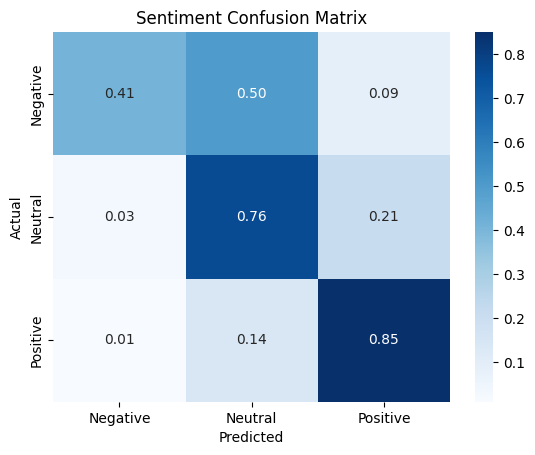

In [24]:
cm = confusion_matrix(all_sentiment_labels, all_sentiment_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure()
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()

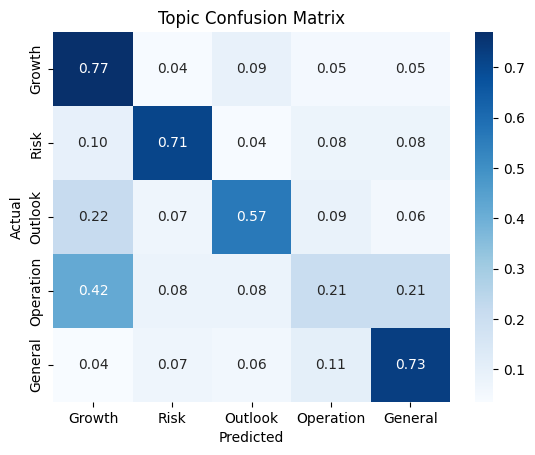

In [25]:
cm = confusion_matrix(all_topic_labels, all_topic_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
plt.figure()
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=["Growth", "Risk", "Outlook", "Operation", "General"],
    yticklabels=["Growth", "Risk", "Outlook", "Operation", "General"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Topic Confusion Matrix")
plt.show()